# Özgün CNN - Stabil ve Daha Az Overfit Eğilimli Sürüm

Bu notebook, önceki sürüme göre daha stabil eğitim için güncellendi:

- Giriş boyutu **320x320**
- **Leakage-free sıralı split**
- Daha küçük ve dengeli özgün CNN
- Daha güçlü regularization
- Daha kontrollü augmentation
- **Early stopping**
- **ReduceLROnPlateau**
- En iyi model kaydı: `ozgun_cnn_final.pt`

> Not: Validation loss küçük veri nedeniyle yine dalgalanabilir. Model seçimi `best val loss` ile yapılır.

In [ ]:
# Gerekli kurulumlar
!pip -q install torch torchvision scikit-learn pandas matplotlib pillow

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import copy
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, roc_curve, auc

Device: cuda
Train: 140 | Val: 30 | Test: 30
Toplam parametre: 295,777
pos_weight: 1.00
Ep 01 | TrL=0.6852 TrA=0.586 | VlL=0.6949 VlA=0.500 | lr=3.00e-04
Ep 02 | TrL=0.6087 TrA=0.686 | VlL=0.6603 VlA=0.533 | lr=3.00e-04
Ep 03 | TrL=0.5998 TrA=0.657 | VlL=0.6989 VlA=0.533 | lr=3.00e-04
Ep 04 | TrL=0.5659 TrA=0.743 | VlL=0.6293 VlA=0.667 | lr=3.00e-04
Ep 05 | TrL=0.5926 TrA=0.714 | VlL=0.5626 VlA=0.700 | lr=3.00e-04
Ep 06 | TrL=0.5862 TrA=0.707 | VlL=0.6140 VlA=0.633 | lr=3.00e-04
Ep 07 | TrL=0.5261 TrA=0.750 | VlL=0.5475 VlA=0.667 | lr=3.00e-04
Ep 08 | TrL=0.5252 TrA=0.729 | VlL=0.6871 VlA=0.667 | lr=3.00e-04
Ep 09 | TrL=0.5040 TrA=0.771 | VlL=0.6738 VlA=0.567 | lr=3.00e-04
Ep 10 | TrL=0.5195 TrA=0.736 | VlL=0.5224 VlA=0.700 | lr=3.00e-04
Ep 11 | TrL=0.6014 TrA=0.650 | VlL=0.6286 VlA=0.633 | lr=3.00e-04
Ep 12 | TrL=0.5406 TrA=0.693 | VlL=0.6477 VlA=0.633 | lr=3.00e-04
Ep 13 | TrL=0.5269 TrA=0.707 | VlL=0.7337 VlA=0.633 | lr=3.00e-04
Ep 14 | TrL=0.5448 TrA=0.700 | VlL=0.5255 VlA=0.767 | 

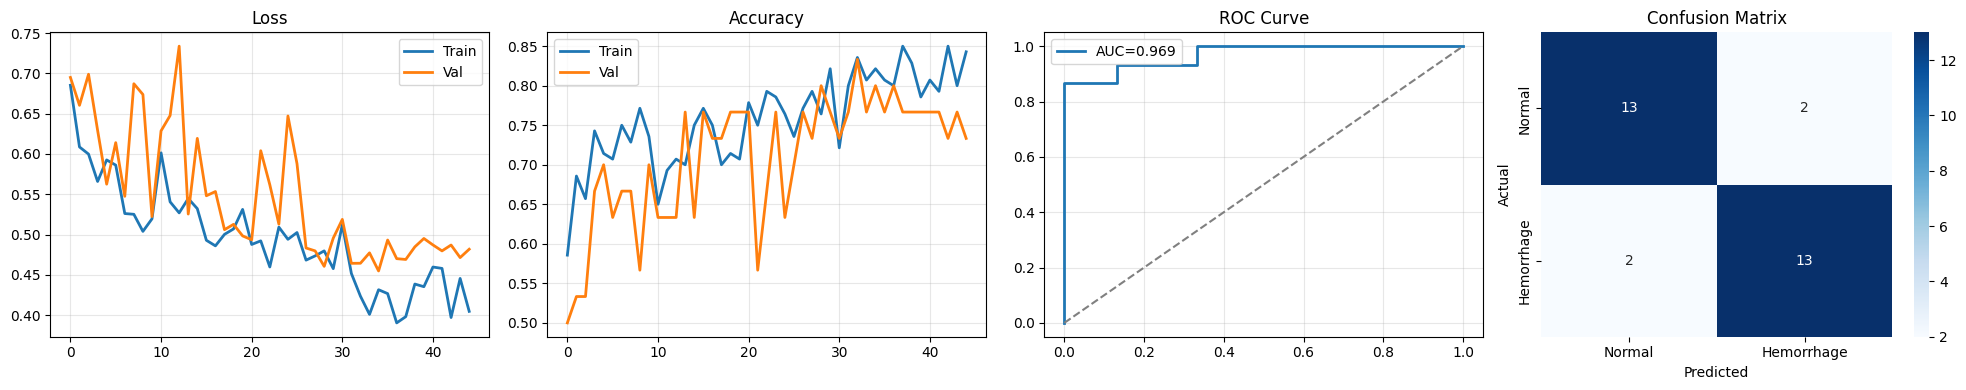

Grafik kaydedildi: hemo_results_v2.png


In [ ]:
# ================================================================
# HemoCT: 200 Görüntü İçin Optimize Edilmiş CNN (v2)
# - Global Average Pooling (GAP) ile parametre sayısı düşürüldü
# - Güçlü augmentation + ElasticTransform
# - Weighted BCELoss (sınıf dengesizliğine karşı)
# - ReduceLROnPlateau scheduler
# - Test seti + Confusion Matrix değerlendirmesi
# ================================================================

import os, copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.transforms import functional as TF
from PIL import Image
import random
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_curve, auc, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. AYARLAR
# ==========================================
IMG_DIR   = "/content/drive/MyDrive/HemoCT_Project/dataset/head_ct"
CSV_PATH  = "/content/drive/MyDrive/HemoCT_Project/dataset/labels.csv"
SAVE_PATH = "hemo_cnn_v2_best.pt"
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMG_SIZE  = 224   # 320 -> 224: GAP ile parametre farkı yoktur ama daha hızlı
BATCH     = 8     # 200 veri ile 16 büyük; 8 daha stabil gradyan
EPOCHS    = 50
LR        = 3e-4
PATIENCE  = 10
print(f"Device: {DEVICE}")

# ==========================================
# 2. ELASTİK TRANSFORM (torchvision'da yok, elle)
# ==========================================
class ElasticTransform:
    """Tıbbi görüntülerde yaygın kullanılan deformasyon augmentation."""
    def __init__(self, alpha=80, sigma=8, p=0.4):
        self.alpha, self.sigma, self.p = alpha, sigma, p

    def __call__(self, img):
        if random.random() > self.p:
            return img
        img_np = np.array(img).astype(np.float32)
        h, w = img_np.shape[:2]
        dx = self._gaussian(np.random.randn(h, w), self.sigma) * self.alpha
        dy = self._gaussian(np.random.randn(h, w), self.sigma) * self.alpha
        x, y = np.meshgrid(np.arange(w), np.arange(h))
        xn = np.clip(x + dx, 0, w - 1).astype(np.float32)
        yn = np.clip(y + dy, 0, h - 1).astype(np.float32)
        from scipy.ndimage import map_coordinates
        if img_np.ndim == 3:
            out = np.stack([map_coordinates(img_np[..., c], [yn.ravel(), xn.ravel()], order=1).reshape(h, w) for c in range(img_np.shape[2])], axis=-1)
        else:
            out = map_coordinates(img_np, [yn.ravel(), xn.ravel()], order=1).reshape(h, w)
        return Image.fromarray(np.clip(out, 0, 255).astype(np.uint8))

    @staticmethod
    def _gaussian(x, sigma):
        from scipy.ndimage import gaussian_filter
        return gaussian_filter(x, sigma)

# ==========================================
# 3. DATASET
# ==========================================
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]  # ImageNet norm (CT grayscale->RGB için makul)

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),          # CT'lerde geçerli
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.9, 1.1)),
    ElasticTransform(alpha=80, sigma=8, p=0.4),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

class HeadCTDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['id']
        path = os.path.join(self.img_dir, f"{int(img_id):03d}.png")
        if not os.path.exists(path):
            path = os.path.join(self.img_dir, str(img_id))
        img = Image.open(path).convert('RGB')
        label = row[' hemorrhage']
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)

# Stratified split: 70 / 15 / 15
df = pd.read_csv(CSV_PATH)
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df[' hemorrhage'])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df[' hemorrhage'])
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train_loader = DataLoader(HeadCTDataset(train_df, IMG_DIR, train_tf), batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(HeadCTDataset(val_df,   IMG_DIR, val_tf),   batch_size=BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(HeadCTDataset(test_df,  IMG_DIR, val_tf),   batch_size=BATCH, shuffle=False, num_workers=2)

# ==========================================
# 4. MODEL (Küçük CNN + GAP)
# ==========================================
# GAP neden önemli?
#  Eski: Flatten → 256*20*20=102.400 parametre → 200 örnekle kesin overfit
#  Yeni: GAP    → 256 parametre → dramatik küçülme

class SmallCNN(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),  # double conv
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            conv_block(3,  32),   # 224 -> 112
            conv_block(32, 64),   # 112 -> 56
            conv_block(64, 128),  # 56  -> 28
            # 4. blok kaldırıldı — daha az parametre
        )
        self.gap = nn.AdaptiveAvgPool2d(1)   # Her kanal için 1 değer
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.gap(x)
        return self.classifier(x)

model = SmallCNN(dropout=0.5).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Toplam parametre: {total_params:,}")  # ~400K civarı olmalı

# ==========================================
# 5. LOSS (weighted) + OPTİMİZER + SCHEDULER
# ==========================================
# Veriye göre pos_weight hesapla (100/100 = 1.0 ama genel formül):
n_neg = (train_df[' hemorrhage'] == 0).sum()
n_pos = (train_df[' hemorrhage'] == 1).sum()
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f"pos_weight: {pos_weight.item():.2f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)  # AdamW + güçlü WD
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

# ==========================================
# 6. EĞİTİM DÖNGÜSÜ
# ==========================================
history = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc']}
best_val_loss = float('inf')
best_weights  = None
patience_ctr  = 0

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    t_loss = t_corr = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(imgs).squeeze(1)
        loss = criterion(out, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()
        t_loss += loss.item() * imgs.size(0)
        t_corr += (torch.sigmoid(out).round() == lbls).sum().item()

    # --- Val ---
    model.eval()
    v_loss = v_corr = 0
    with torch.no_grad():
        for imgs, lbls in val_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            out     = model(imgs).squeeze(1)
            v_loss += criterion(out, lbls).item() * imgs.size(0)
            v_corr += (torch.sigmoid(out).round() == lbls).sum().item()

    tl = t_loss / len(train_df); vl = v_loss / len(val_df)
    ta = t_corr / len(train_df); va = v_corr / len(val_df)
    history['train_loss'].append(tl); history['val_loss'].append(vl)
    history['train_acc'].append(ta);  history['val_acc'].append(va)
    scheduler.step(vl)

    print(f"Ep {epoch:02d} | TrL={tl:.4f} TrA={ta:.3f} | VlL={vl:.4f} VlA={va:.3f} | lr={optimizer.param_groups[0]['lr']:.2e}")

    if vl < best_val_loss:
        best_val_loss = vl
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, SAVE_PATH)
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"Early stop @ epoch {epoch}")
            break

# ==========================================
# 7. TEST DEĞERLENDİRMESİ
# ==========================================
model.load_state_dict(best_weights)
model.eval()
all_probs, all_preds, all_lbls = [], [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        probs = torch.sigmoid(model(imgs).squeeze(1)).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend((probs > 0.5).astype(int))
        all_lbls.extend(lbls.numpy().astype(int))

print("\n========== TEST SONUÇLARI ==========")
print(f"Accuracy : {accuracy_score(all_lbls, all_preds):.4f}")
print(f"Precision: {precision_score(all_lbls, all_preds, zero_division=0):.4f}")
print(f"Recall   : {recall_score(all_lbls, all_preds, zero_division=0):.4f}")
print(f"F1 Score : {f1_score(all_lbls, all_preds, zero_division=0):.4f}")
fpr, tpr, _ = roc_curve(all_lbls, all_probs)
print(f"AUC-ROC  : {auc(fpr, tpr):.4f}")
print("=====================================")

# ==========================================
# 8. GÖRSELLEŞTİRME
# ==========================================
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train', lw=2)
axes[0].plot(history['val_loss'],   label='Val',   lw=2)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', lw=2)
axes[1].plot(history['val_acc'],   label='Val',   lw=2)
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

# ROC
axes[2].plot(fpr, tpr, lw=2, label=f'AUC={auc(fpr,tpr):.3f}')
axes[2].plot([0,1],[0,1],'--', color='gray')
axes[2].set_title('ROC Curve'); axes[2].legend(); axes[2].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(all_lbls, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[3],
            xticklabels=['Normal','Hemorrhage'], yticklabels=['Normal','Hemorrhage'])
axes[3].set_title('Confusion Matrix'); axes[3].set_ylabel('Actual'); axes[3].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig("hemo_results_v2.png", dpi=150, bbox_inches='tight')
plt.show()
print("Grafik kaydedildi: hemo_results_v2.png")

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Modelin en iyi ağırlıklarını yükle ve değerlendirme moduna al
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

all_preds = []
all_labels = []

# Test seti için data loader oluştur (eğer yukarıda oluşturulmadıysa)
test_loader = DataLoader(HeadCTDataset(test_df, IMG_DIR, val_test_transforms), batch_size=16, shuffle=False)

print("Test seti üzerinde değerlendirme yapılıyor...\n")

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images).squeeze(1)
        preds = (torch.sigmoid(outputs) > 0.5).float()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 2. Metrikleri hesapla
acc = accuracy_score(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=["Normal (0)", "Hemoraji (1)"])

print(f"Genel Test Doğruluğu (Accuracy): %{acc*100:.2f}")
print("\nDetaylı Sınıflandırma Raporu:")
print(report)

# 3. Confusion Matrix Çizdirme
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Normal (Tahmin)", "Hemoraji (Tahmin)"],
            yticklabels=["Normal (Gerçek)", "Hemoraji (Gerçek)"])

plt.title('Confusion Matrix - Test Verisi')
plt.ylabel('Gerçek Sınıf')
plt.xlabel('Tahmin Edilen Sınıf')
plt.show()


NameError: name 'val_test_transforms' is not defined